<a href="https://colab.research.google.com/github/wookgom/2026-1_CV/blob/main/26-1_CV_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 환경 세팅

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlretrieve

# 이미지 다운로드 함수
def download_image(url, save_name):
    urlretrieve(url, save_name)
    return save_name

# 이미지 출력 함수
def show(images, titles=None, cols=3):
    if not isinstance(images, list):
        images = [images]

    n = len(images)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i], cmap='gray')
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## HW#2-1

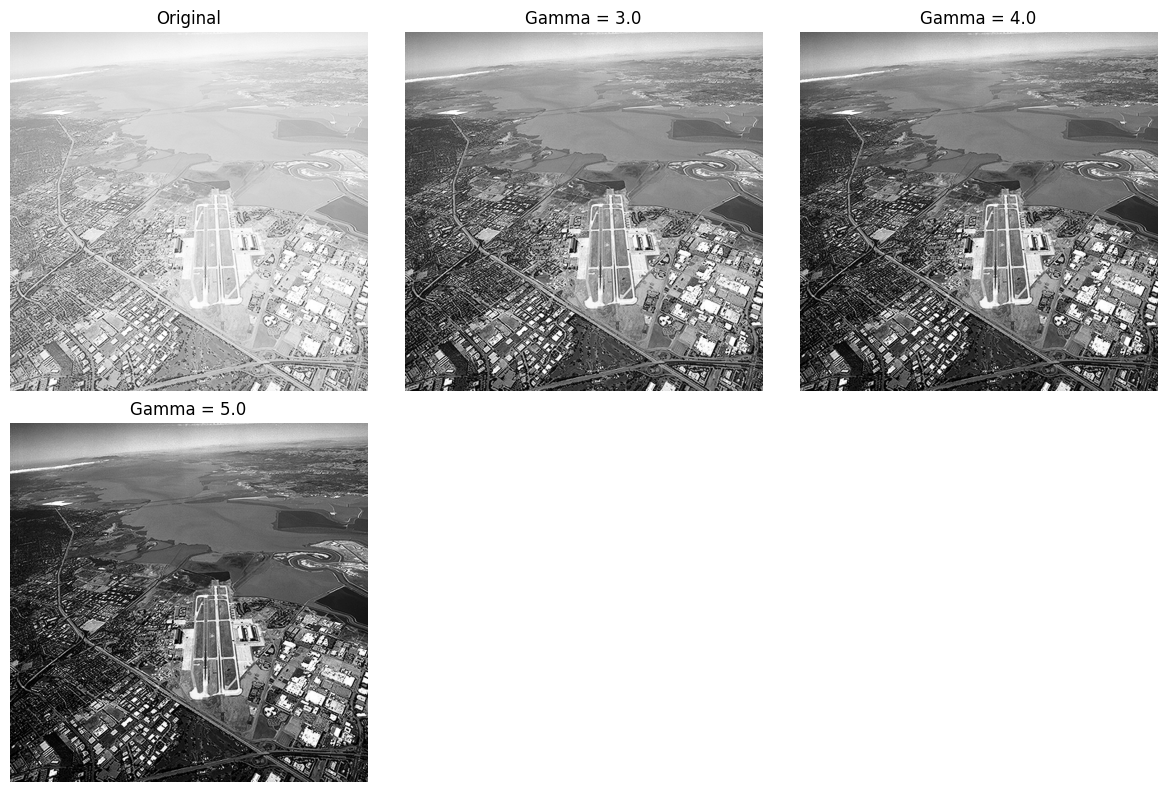

In [ ]:
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif"
path = download_image(url, "aerial.tif")
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# 감마 변환 함수
def gamma_transform(img, gamma):
    img = img / 255.0          # 0~1 정규화
    out = np.power(img, gamma)
    out = (out * 255).astype(np.uint8)
    return out

# 결과 생성
g3 = gamma_transform(img, 3.0)
g4 = gamma_transform(img, 4.0)
g5 = gamma_transform(img, 5.0)

# 출력
show(
    [img, g3, g4, g5],
    ["Original", "Gamma = 3.0", "Gamma = 4.0", "Gamma = 5.0"]
)

### 결과 분석
감마값을 3.0, 4.0, 5.0으로 증가시키면서 실험한 결과, 감마값이 커질수록 영상의 밝은 영역이 상대적으로 억제되고 어두운 영역과의 차이가 커져 전체 대비가 향상되었다. 감마값이 작은 경우에는 원본보다 약간 또렷해졌지만 개선 효과가 비교적 약했고, 감마값이 너무 커지면 영상이 지나치게 어두워지면서 일부 세부 정보가 손실되는 경향이 나타났다. 따라서 감마 변환은 저대비 영상을 개선하는 데 효과적이지만, 감마값이 지나치게 크면 정보 손실이 발생할 수 있으므로 적절한 값 선택이 중요하다.

## HW#2-2

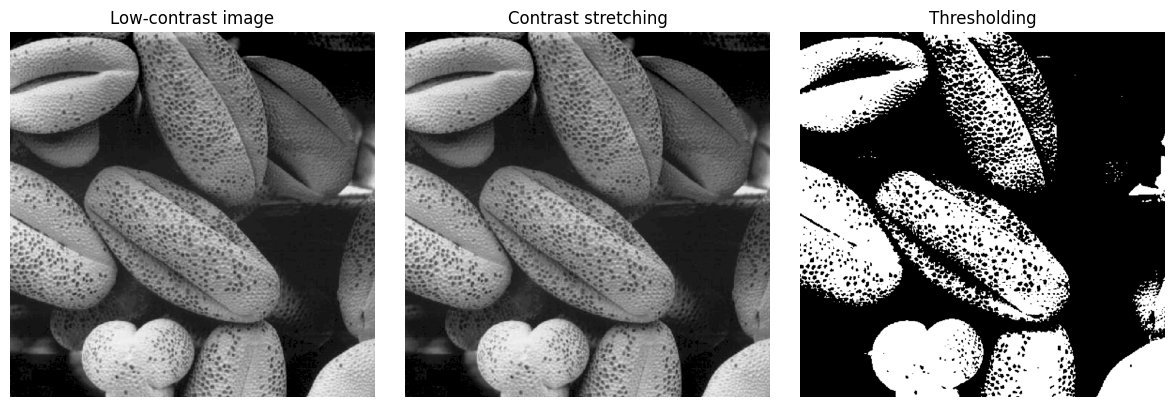

In [ ]:
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif"
path = download_image(url, "pollen.tif")
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# contrast stretching
mn, mx = img.min(), img.max()
stretch = ((img.astype(np.float32) - mn) / (mx - mn) * 255).astype(np.uint8)

# thresholding
_, thresh = cv2.threshold(stretch, 120, 255, cv2.THRESH_BINARY)

show(
    [img, stretch, thresh],
    ["Low-contrast image", "Contrast stretching", "Thresholding"]
)

### 결과 분석
입력 영상은 저대비 영상이므로 원본 상태에서는 객체와 배경의 구분이 뚜렷하지 않았다. 이를 개선하기 위해 contrast stretching을 적용하여 입력 명암 범위를 더 넓은 출력 범위로 확장하였음. 그 결과 원래 좁은 범위에 몰려 있던 밝기값이 넓게 퍼지면서 객체와 배경의 차이가 더 분명해졌고, 세부 구조도 원본보다 선명하게 보였다.

이후 contrast stretching 결과에 thresholding을 적용하였다. thresholding 결과는 객체와 배경을 이진적으로 분리할 수 있다는 장점이 있었지만, 임계값 선택에 따라 일부 세부 정보가 사라지거나 과도하게 강조되는 현상이 나타날 수 있었다.

즉 contrast stretching은 저대비 영상의 시각적 개선에 적합하고, thresholding은 객체 분리에 적합하지만 세부 명암 정보는 유지하지 못한다는 차이가 확인되었다.


## HW#2-3

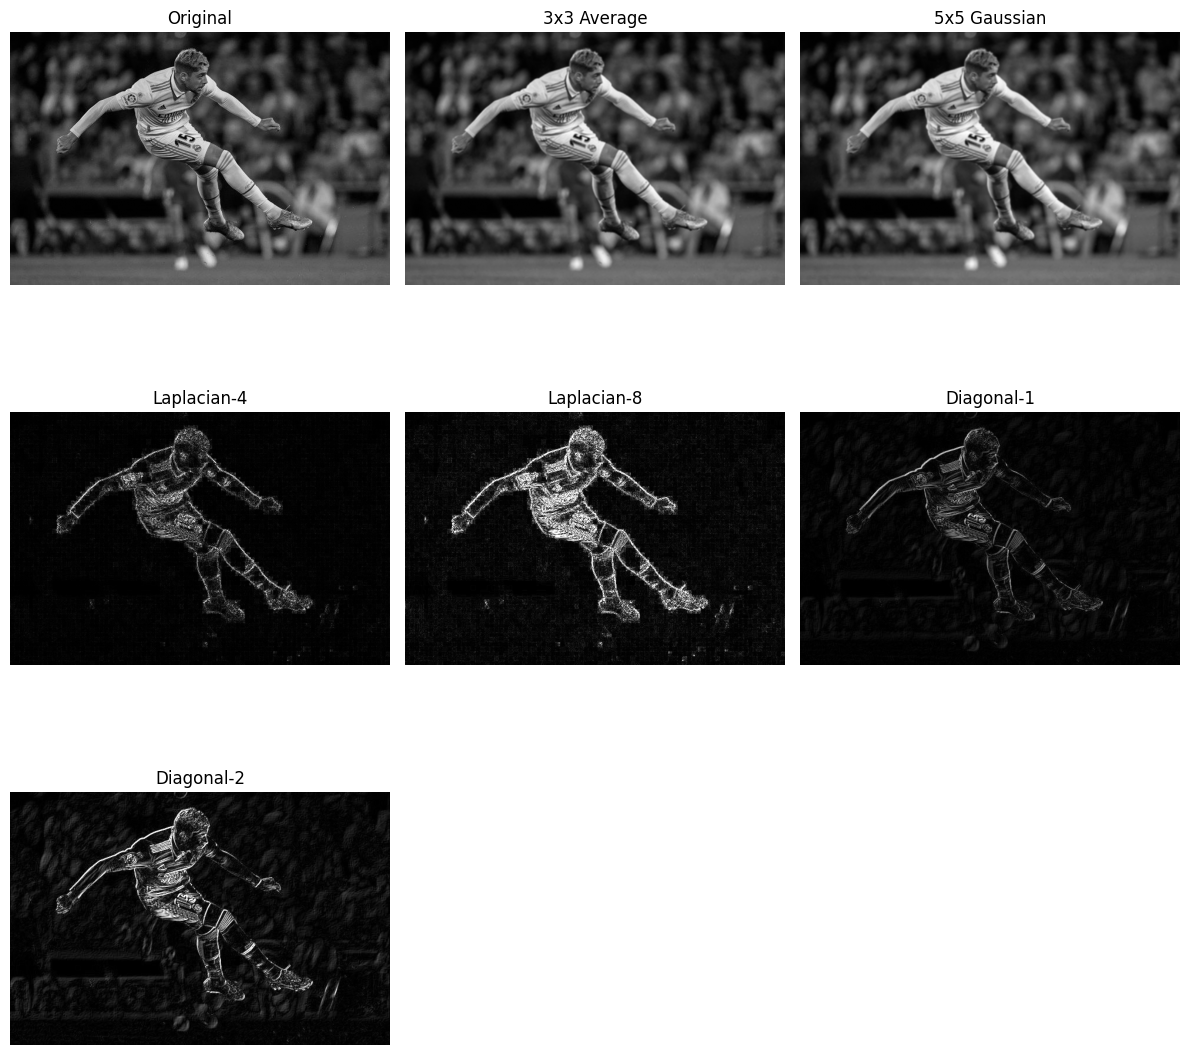

In [92]:
path = "/content/shooting.jpeg"
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

m1 = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)

m2 = np.array([
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]
], dtype=np.float32)

m3 = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)

m4 = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

m5 = np.array([
    [-1, 0, 0],
    [ 0, 0, 0],
    [ 0, 0, 1]
], dtype=np.float32)

m6 = np.array([
    [-1, -1, 0],
    [-1,  0, 1],
    [ 0,  1, 1]
], dtype=np.float32)

r1 = cv2.filter2D(img, -1, m1)
r2 = cv2.filter2D(img, -1, m2)

r3 = cv2.filter2D(img, cv2.CV_32F, m3)
r4 = cv2.filter2D(img, cv2.CV_32F, m4)
r5 = cv2.filter2D(img, cv2.CV_32F, m5)
r6 = cv2.filter2D(img, cv2.CV_32F, m6)

r3 = cv2.convertScaleAbs(r3)
r4 = cv2.convertScaleAbs(r4)
r5 = cv2.convertScaleAbs(r5)
r6 = cv2.convertScaleAbs(r6)

show(
    [img, r1, r2, r3, r4, r5, r6],
    ["Original", "3x3 Average", "5x5 Gaussian", "Laplacian-4", "Laplacian-8", "Diagonal-1", "Diagonal-2"]
)

### 결과 분석
Average 마스크와 Gaussian 마스크는 영상을 부드럽게 만들어 잡음을 줄였지만 경계가 흐려졌다. Laplacian 마스크는 edge를 강조하는 효과가 크게 나타났다. Diagonal 방향 마스크는 특정 방향의 성분만 강조되어 방향성 특징을 확인할 수 있었다.

## HW#2-4

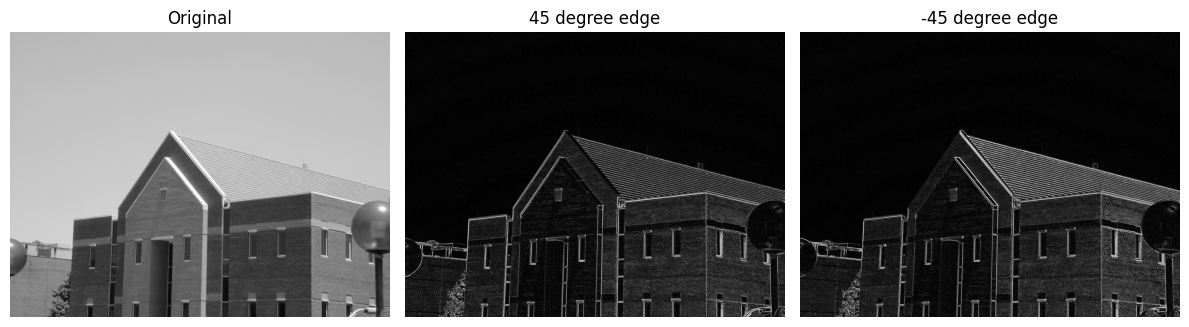

In [ ]:
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/school.jpg"
path = download_image(url, "school.jpg")
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# 45도, -45도 방향 Sobel 변형 마스크
k1 = np.array([
    [-2, -1,  0],
    [-1,  0,  1],
    [ 0,  1,  2]
], dtype=np.float32)

k2 = np.array([
    [ 0,  1,  2],
    [-1,  0,  1],
    [-2, -1,  0]
], dtype=np.float32)

e1 = cv2.filter2D(img, cv2.CV_32F, k1)
e2 = cv2.filter2D(img, cv2.CV_32F, k2)

e1 = cv2.convertScaleAbs(e1)
e2 = cv2.convertScaleAbs(e2)

show(
    [img, e1, e2],
    ["Original", "45 degree edge", "-45 degree edge"],
    cols=3
)

## HW#2-5

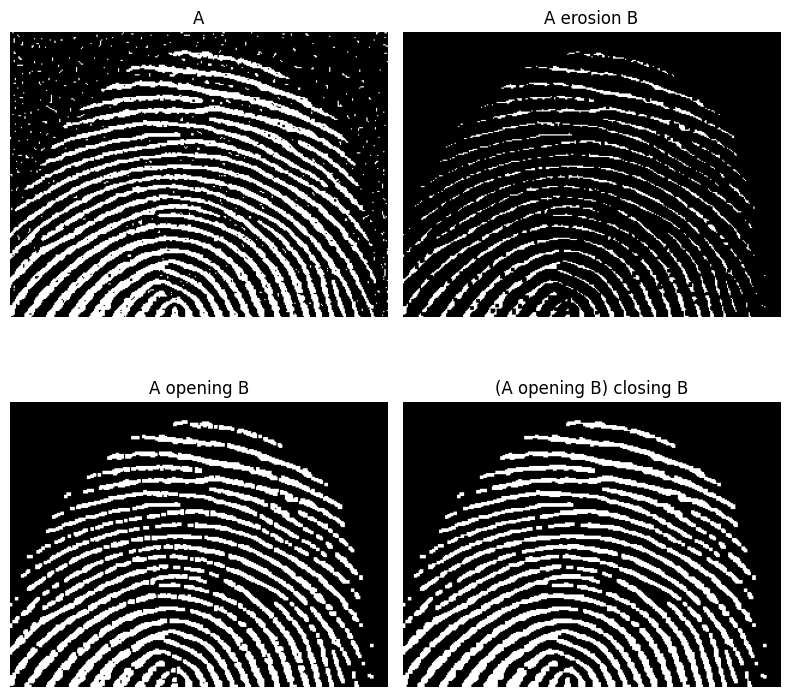

In [ ]:
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/finger.jpg"
path = download_image(url, "finger.jpg")
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((3, 3), np.uint8)

eroded = cv2.erode(binary, kernel, iterations=1)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed_after_open = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

show(
    [binary, eroded, opened, closed_after_open],
    ["A", "A erosion B", "A opening B", "(A opening B) closing B"],
    cols=2
)

### 결과 분석
지문 영상에 대해 이진화와 morphology를 적용하자 작은 점 잡음이 줄어들고 ridge가 더 뚜렷해졌다. Opening은 작은 잡음 제거에 효과적이었고, closing은 끊긴 ridge를 일부 보완하는 데 도움이 되었다. 따라서 원본보다 더 선명한 지문 영상을 얻을 수 있었다

### 더 좋은 방법
먼저 지문 영상에 blur를 적용해 작은 잡음을 완화했다. 이렇게 하면 원본에 있던 점 형태의 노이즈가 줄어들어 이후 이진화 결과가 더 안정적으로 나온다.
그다음 이진화를 적용해 지문 ridge와 배경을 분리한 뒤에 opening을 적용해 작은 흰색 잡음을 제거했다. 마지막으로 closing을 적용해 끊겨 보이는 ridge를 일부 보완하여 기존 방식 보다 지문 선이 더 연속적이고 선명하게 보이도록 만들었다.

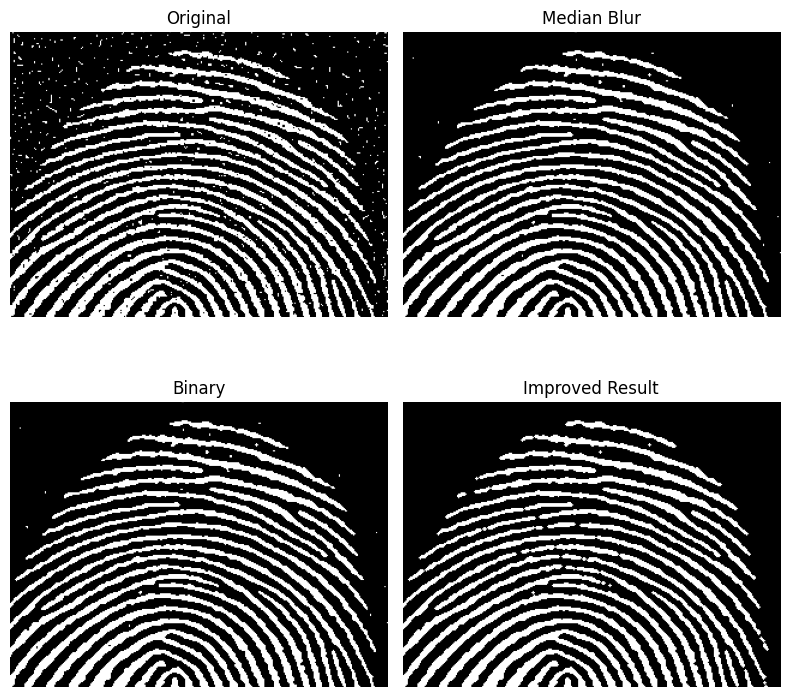

In [ ]:
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/finger.jpg"
path = download_image(url, "finger.jpg")
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

blur = cv2.medianBlur(img, 3)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
result = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

show(
    [img, blur, binary, result],
    ["Original", "Median Blur", "Binary", "Improved Result"],
    cols=2
)

## HW#2-6

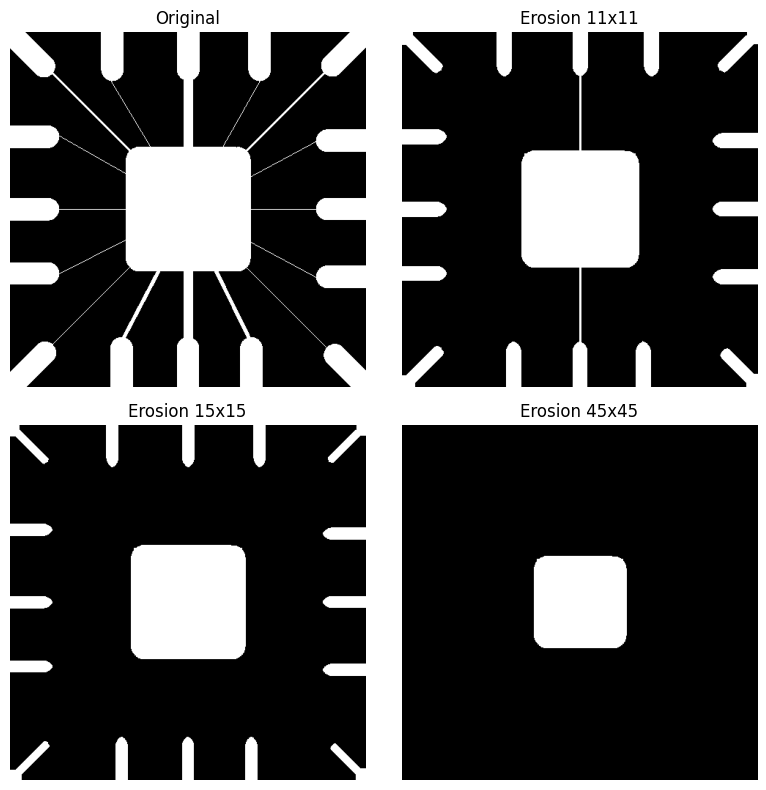

In [ ]:
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0905(a)(wirebond-mask).tif"
path = download_image(url, "wirebond.tif")
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# 이진화
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# square structuring element
k11 = np.ones((11, 11), np.uint8)
k15 = np.ones((15, 15), np.uint8)
k45 = np.ones((45, 45), np.uint8)

# erosion
e11 = cv2.erode(binary, k11, iterations=1)
e15 = cv2.erode(binary, k15, iterations=1)
e45 = cv2.erode(binary, k45, iterations=1)

show(
    [binary, e11, e15, e45],
    ["Original", "Erosion 11x11", "Erosion 15x15", "Erosion 45x45"],
    cols=2
)

### 어떻게 했는지 분석
먼저 영상을 이진화하여 배경과 객체를 분리하였다. 이후 morphology를 적용해 얇은 wire 성분을 제거하였다. 얇은 선은 구조요소보다 폭이 작아서 먼저 사라지고, 큰 pad나 중앙 구조는 상대적으로 유지되었다. 즉 객체의 두께 차이를 이용해 선분을 제거하였다.

## HW#2-7

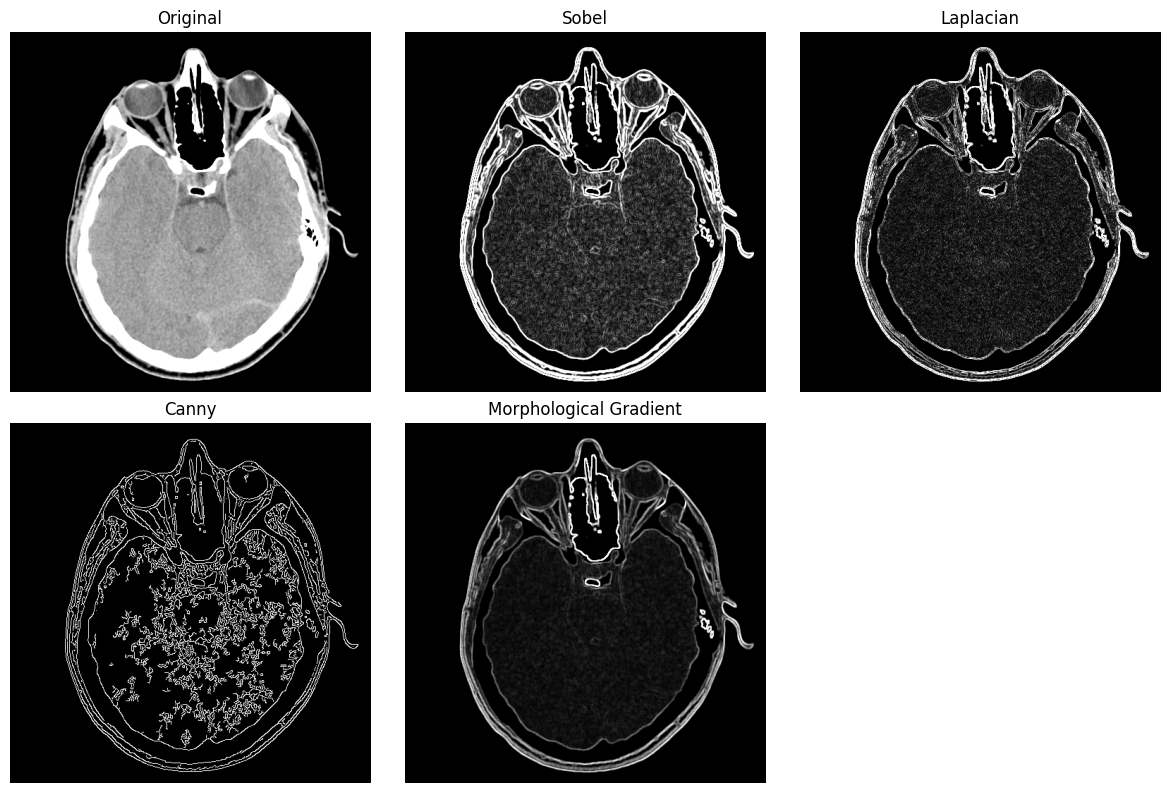

In [ ]:
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0939(a)(headCT-Vandy).tif"
path = download_image(url, "headct.tif")
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# Sobel
sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sx, sy)
sobel = cv2.convertScaleAbs(sobel)

# Laplacian
laplacian = cv2.Laplacian(img, cv2.CV_64F, ksize=3)
laplacian = cv2.convertScaleAbs(laplacian)

# Canny
canny = cv2.Canny(img, 50, 150)

# Morphological Gradient
kernel = np.ones((3, 3), np.uint8)
morph = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

show(
    [img, sobel, laplacian, canny, morph],
    ["Original", "Sobel", "Laplacian", "Canny", "Morphological Gradient"],
    cols=3
)

### 결과 비교
- Sobel은 전체 edge를 부드럽게 보여주었다.
- Laplacian은 edge에 더 민감하여 세부 변화가 강하게 나타났다.
- Canny는 가장 얇고 깔끔한 edge를 검출했다.
- Morphological Gradient는 물체의 외곽 경계를 두껍게 강조하는 결과를 보였다.

## HW#2-8

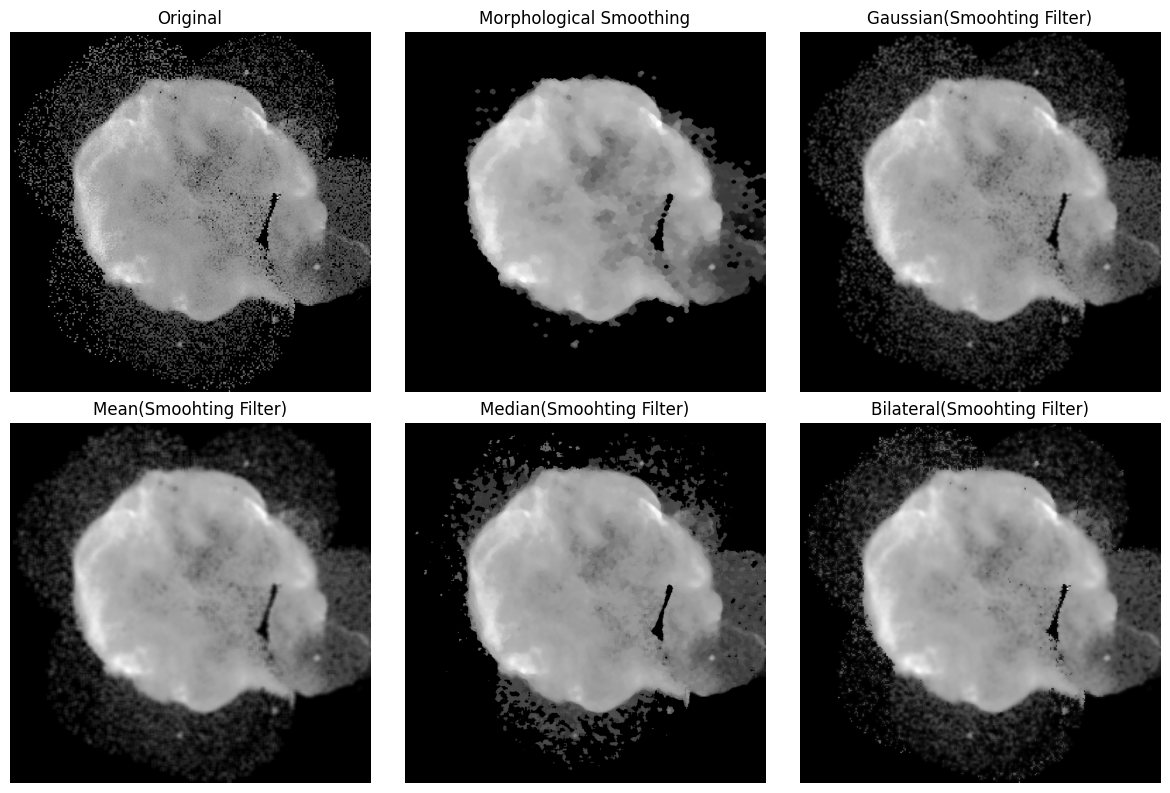

In [93]:
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0938(a)(cygnusloop_Xray_original).tif"
path = download_image(url, "xray.tif")
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# Morphological smoothing
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
morph = cv2.morphologyEx(img, cv2.MORPH_OPEN, k)
morph = cv2.morphologyEx(morph, cv2.MORPH_CLOSE, k)

# Smoothing filters
gaussian = cv2.GaussianBlur(img, (7, 7), 0)
mean = cv2.blur(img, (7, 7))
median = cv2.medianBlur(img, 7)
bilateral = cv2.bilateralFilter(img, 9, 75, 75)

show(
    [img, morph, gaussian, mean, median, bilateral],
    ["Original", "Morphological Smoothing", "Gaussian(Smoohting Filter)", "Mean(Smoohting Filter)"
    , "Median(Smoohting Filter)", "Bilateral(Smoohting Filter)"],
    cols=3
)

### 결과 비교
- Morphological smoothing은 작은 점 잡음을 제거하는 데 효과적이었고, 객체 형태를 비교적 잘 유지했다.
- smoothing filter는 영상 전체를 부드럽게 만들었지만 경계도 함께 흐려졌다.

- 즉 morphology는 형태적 잡음 제거에 강하고, smoothing filter는 전반적인 평활화에 적합하다는 차이가 있었다.

## HW#2-9

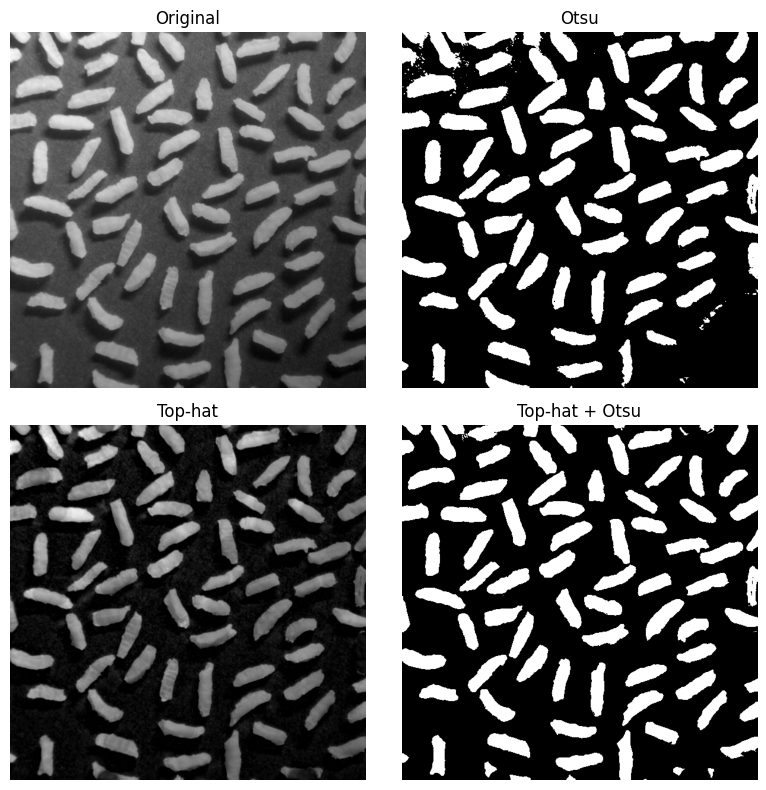

In [ ]:
url = "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0940(a)(rice_image_with_intensity_gradient).tif"
path = download_image(url, "rice.tif")
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# 원본 영상에 대한 Otsu 이진화
_, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Top-hat 변환 후 Otsu 이진화
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
_, tophat_otsu = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show(
    [img, otsu, tophat, tophat_otsu],
    ["Original", "Otsu", "Top-hat", "Top-hat + Otsu"],
    cols=2
)

### 결과 비교
- 원본 영상에 바로 Otsu 이진화를 적용하면 밝기 gradient의 영향을 받아 일부 영역에서 분리가 불안정할 수 있었다.
- Top-hat 변환 후 Otsu 이진화를 적용하면 배경 밝기 변화가 줄어들어 쌀알이 더 균일하게 분리되었다.

- 따라서 Top-hat + Otsu 방법이 더 안정적인 결과를 보였다.

## HW#2-10

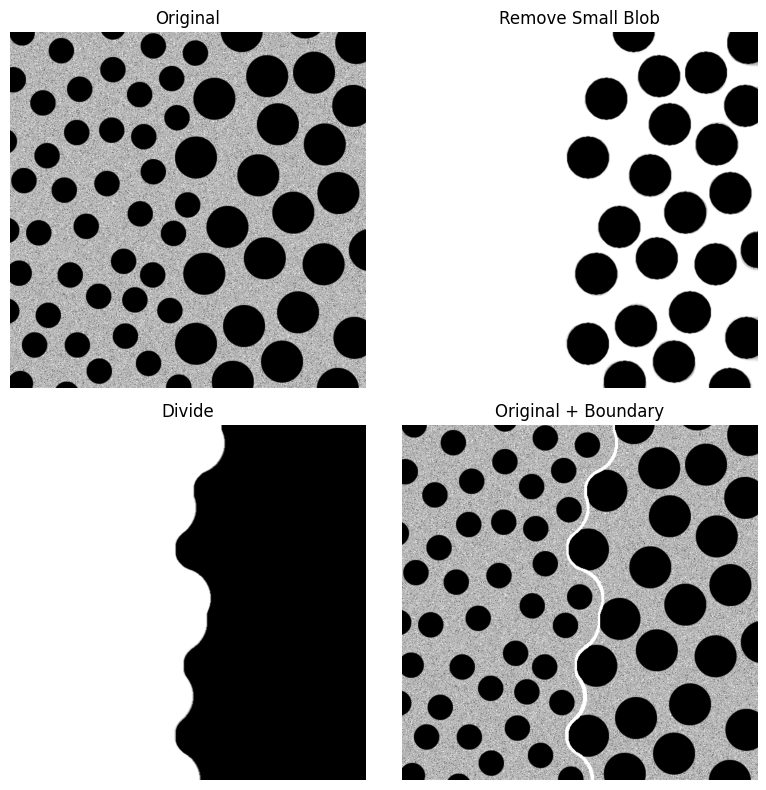

In [88]:
url = 'https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0943(a)(dark_blobs_on_light_background).tif'
path = download_image(url, 'blobs.tif')
img = cv2.imread(path, 0)

# closing을 통해 작은 점 제거
k1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (55,55))
remove_small_blob = cv2.morphologyEx(img, cv2.MORPH_CLOSE, k1)

# opening을 통해 큰 점, 작은 점 영역 나누기
k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (100,100))
divide = cv2.morphologyEx(remove_small_blob, cv2.MORPH_OPEN, k2)

# boundary 검출
k3 = np.ones((3, 3), np.uint8)
boundary = cv2.morphologyEx(divide, cv2.MORPH_GRADIENT, k3)

# original과 boundary 병합
result = img.copy()
result[boundary > 0] = 255


show(
    [img, remove_small_blob, divide, result ],
    ['Original', 'Remove Small Blob', 'Divide', 'Original + Boundary'],
    cols=2
)